# Setup python session and notebook

In [38]:
import numpy as np
import pencil as pc
import matplotlib.pyplot as plt
import os
from utils import *
plt.rcParams['text.usetex'] = True

Evolution of the Chiral Chemical Potential $\mu_5$

The evolution equation for the chiral chemical potential $\mu_5$ can be written as:

\begin{equation}
\frac{\partial \mu_5}{\partial t} = \lambda_5 \mathbf{E} \cdot \mathbf{B} - \Gamma_{f5} \mu_5 + \text{S}_5
\end{equation}

where:

$\mu_5$ is the chiral chemical potential

$\lambda_5$ is the chiral anomaly coefficient

$\Gamma_{f5}$ is the chirality flipping rate (damping coefficient)

$\text{source}_5$ represents additional sources of chirality

In the code, $\mathbf{E} \cdot \mathbf{B}$ is computed as $\eta(\mathbf{j} \cdot \mathbf{B} - \mu_5 B^2)$, where $\eta$ is the resistivity and $\mathbf{j}$ is the current density.

Comments: Think about the length scales.


# Get simulation as object

In [54]:
SIMns = pc.get_sim('runs_directory2/no_source')
SIMss = pc.get_sim('runs_directory2/smooth_source')
SIMss2 = pc.get_sim('runs_directory2/smooth_source2')
SIMss2mu0 = pc.get_sim('runs_directory2/smooth_source2_mu0')

File /home/mgurgeni/programming/mhd_project/runs_directory2/no_source/data/proc980/dim.dat could not be opened.
? WARNING: Couldnt load grid for /home/mgurgeni/programming/mhd_project/runs_directory2/no_source
File /home/mgurgeni/programming/mhd_project/runs_directory2/smooth_source/data/proc980/dim.dat could not be opened.
? WARNING: Couldnt load grid for /home/mgurgeni/programming/mhd_project/runs_directory2/smooth_source
File /home/mgurgeni/programming/mhd_project/runs_directory2/smooth_source2/data/proc980/dim.dat could not be opened.
? WARNING: Couldnt load grid for /home/mgurgeni/programming/mhd_project/runs_directory2/smooth_source2
File /home/mgurgeni/programming/mhd_project/runs_directory2/smooth_source2/data/proc980/dim.dat could not be opened.
? WARNING: Couldnt load grid for /home/mgurgeni/programming/mhd_project/runs_directory2/smooth_source2
? Warning: sim.dill in runs_directory2/smooth_source2_mu0 is not up to date, recreating simulation object..


## Read timeseries

In [59]:
tsns = pc.read.ts(file_name="time_series.dat",datadir=SIMns.datadir)
tsss = pc.read.ts(file_name="time_series.dat",datadir=SIMss.datadir)
tsss2 = pc.read.ts(file_name="time_series.dat",datadir=SIMss2.datadir)
tsss2mu0 = pc.read.ts(file_name="time_series.dat",datadir=SIMss2mu0.datadir)
tsall = [tsns,tsss,tsss2,tsss2mu0]
labels = ['no_source',"smooth","smaller values","no intial mu"]

Read 600 lines.
Read 291 lines.
Read 600 lines.
Invalid data on line 2. Skipping.
Invalid data on line 3. Skipping.
Invalid data on line 4. Skipping.
Invalid data on line 5. Skipping.
Invalid data on line 6. Skipping.
Invalid data on line 7. Skipping.
Invalid data on line 8. Skipping.
Invalid data on line 9. Skipping.
Invalid data on line 10. Skipping.
Invalid data on line 11. Skipping.
Invalid data on line 12. Skipping.
Invalid data on line 13. Skipping.
Invalid data on line 14. Skipping.
Invalid data on line 15. Skipping.
Invalid data on line 16. Skipping.
Invalid data on line 17. Skipping.
Read 584 lines.


## Reading Power


In [56]:
params_ns = pc.read.param(datadir=SIMns.datadir,param2=True)
params_ss = pc.read.param(datadir=SIMss.datadir,param2=True)
params_ss2 = pc.read.param(datadir=SIMss2.datadir,param2=True)
params_ss2mu0 = pc.read.param(datadir=SIMss2mu0.datadir,param2=True)

params_all = [params_ns,params_ss,params_ss2 ]
params_labels = ['no_source',"Smooth","Smooth2","Smooth2mu0" ]

In [ ]:
pwns = pc.read.power(datadir=SIMns.datadir)
pwss = pc.read.power(datadir=SIMss.datadir)
pwss2 = pc.read.power(datadir=SIMss2.datadir)
pwss2mu0 = pc.read.power(datadir=SIMss2mu0.datadir)

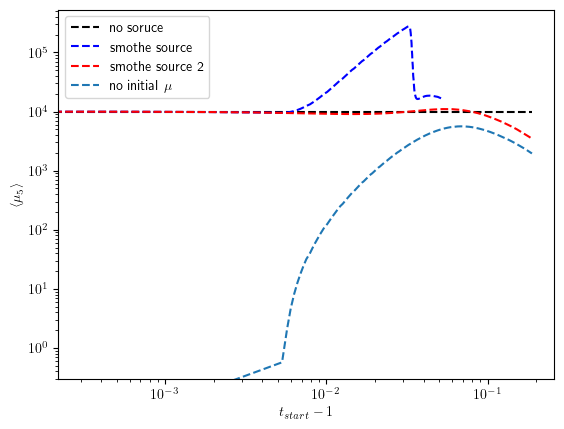

In [78]:
plt.loglog(tsns.t-1,tsns.mu5m,"--",color = "Black",label = "no soruce")
plt.loglog(tsss.t-1,tsss.mu5m,"--",color = "Blue",label = "smothe source")
plt.loglog(tsss2.t-1,tsss2.mu5m,"--",color = "Red",label ="smothe source 2")
plt.loglog(tsss2mu0.t-1,tsss2mu0.mu5m,"--",label = r"no initial $\mu$")
plt.legend()
plt.xlabel(r"$t_{start}-1$")
plt.ylabel(r"$\langle \mu_5 \rangle $")
plt.show()





In [45]:
# analitical calculation of source teram
y_values = (tsss2.t-1) * np.exp(-params_ss2.source5_expt2* ( tsss2.t -1)**2)

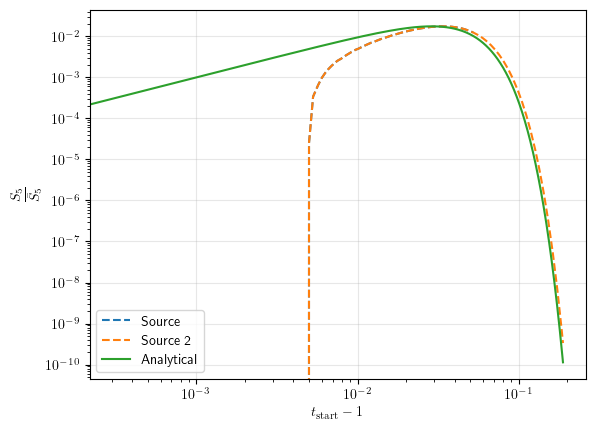

In [46]:
plt.loglog(tsss.t - 1, tsss.srce5m / params_ss.source5,
           "--", label=r"Source")

plt.loglog(tsss2.t - 1, tsss2.srce5m / params_ss2.source5,
           "--", label=r"Source 2")

plt.loglog(tsss2.t - 1, y_values, label=r"Analytical")

plt.xlabel(r"$t_{\mathrm{start}} - 1$")
plt.ylabel(r"$\displaystyle \frac{S_{5}}{\bar{S}_{5}}$")
plt.legend()
plt.grid(alpha=0.3)

# Reading parameters from the corespontid simulations

Here I will show all the paeremaeteres used in the conresponding simultatuon

In [47]:
#Sources parameters for all simulations
for id,sim in enumerate(params_all):
    print("____________________")
    print(f"key: {params_labels[id]}")
    print(f"source5: {params_all[id].source5:e}")
    print(f"source5_tdep: {params_all[id].source5_tdep}")
    print(f"source5_expt2: {params_all[id].source5_expt2}")
    print(f"gammaf5: {params_all[id].gammaf5:e}")
    print(f"t1_source5: {params_all[id].t1_source5}")
    print(f"t2_source5: {params_all[id].t2_source5}")
    print(f"{params_all[id].source5_expt2}")


____________________
key: no_source
source5: 0.000000e+00
source5_tdep: const
source5_expt2: 0.0
gammaf5: 0.000000e+00
t1_source5: 0.0
t2_source5: 0.0
0.0
____________________
key: Smooth
source5: 1.000000e+09
source5_tdep: smooth_source
source5_expt2: 600.0
gammaf5: 1.000000e+01
t1_source5: 1.005
t2_source5: 0.0
600.0
____________________
key: Smooth2
source5: 1.000000e+07
source5_tdep: smooth_source
source5_expt2: 600.0
gammaf5: 1.000000e+01
t1_source5: 1.005
t2_source5: 0.0
600.0


## Generating power spectrum

### general test 

In [48]:
# read powr spec
pwns = pc.read.power(datadir=SIMns.datadir)
print(pwns.krms)

power_GWh.dat
File /home/mgurgeni/programming/mhd_project/runs_directory2/no_source/data/proc980/dim.dat could not be opened.
powerhel_GWs.dat
power_Tpq.dat
power_Str.dat
powerhel_kin.dat
power_GWs.dat
powerhel_mag.dat
power_sp.dat
power_krms.dat
power_SCL.dat
power_mag.dat
powerhel_Str.dat
power_VCT.dat
power_kin.dat
powerhel_GWh.dat
[ 0.    1.29  2.24  3.14  4.07  5.11  6.13  7.08  8.03  9.06 10.1  11.1
 12.   13.   14.1  15.  ]


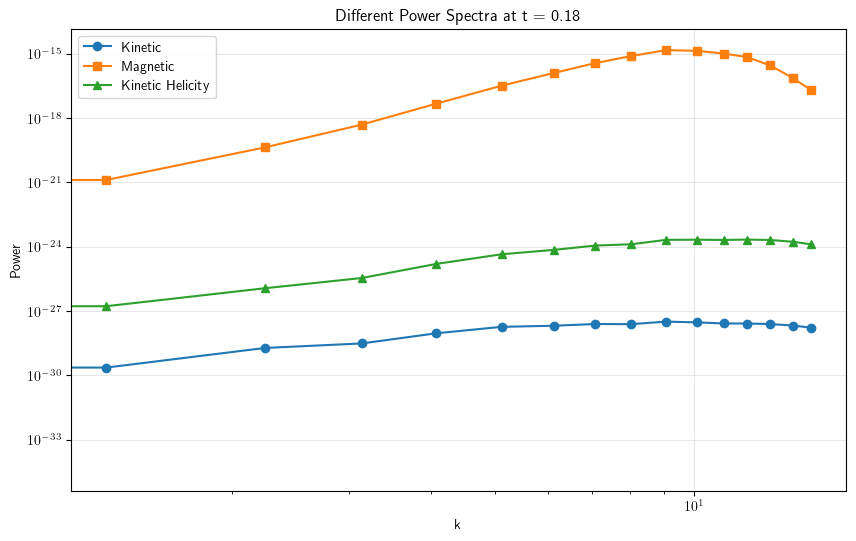

In [49]:
# Compare different types of spectra at the same time
plt.figure(figsize=(10, 6))

# Check if these spectra exist before plotting
if hasattr(pwns, 'kin'):
    plt.loglog(pwns.krms, pwns.kin[-1], 'o-', label='Kinetic')
if hasattr(pwns, 'mag'):
    plt.loglog(pwns.krms, pwns.mag[-1], 's-', label='Magnetic')
if hasattr(pwns, 'hel_kin'):
    plt.loglog(pwns.krms, np.abs(pwns.hel_kin[-1]), '^-', label='Kinetic Helicity')

plt.xlabel('k')
plt.ylabel('Power')
plt.title(f'Different Power Spectra at t = {pwns.t[-1]-1:.2f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

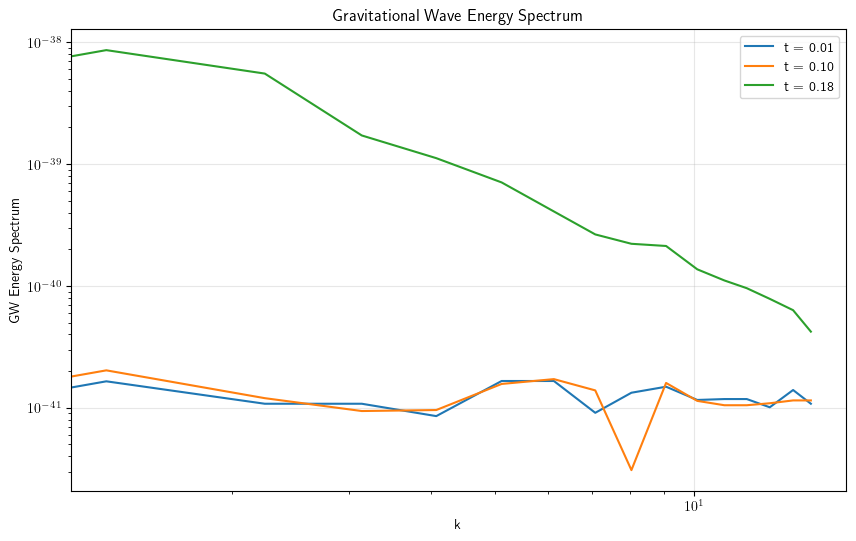

In [50]:
plt.figure(figsize=(10, 6))

# Plot the spectrum at different times
times = [0, len(pwns.t)//2, -1]  
for idx in times:
    plt.loglog(pwns.krms, pwns.GWs[idx],  label=f't = {pwns.t[idx]-1:.2f}')

plt.xlabel('k')
plt.ylabel('GW Energy Spectrum')
plt.title('Gravitational Wave Energy Spectrum')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Power for the simultations

In [51]:
pwns = pc.read.power(datadir=SIMns.datadir)
pwss = pc.read.power(datadir=SIMss.datadir)
pwss2 = pc.read.power(datadir=SIMss2.datadir)

powers_all = [pwns, pwss, pwss2]
powers_labels = ['no_source', 'smooth_source',"smooth2"]

power_GWh.dat
File /home/mgurgeni/programming/mhd_project/runs_directory2/no_source/data/proc980/dim.dat could not be opened.
powerhel_GWs.dat
power_Tpq.dat
power_Str.dat
powerhel_kin.dat
power_GWs.dat
powerhel_mag.dat
power_sp.dat
power_krms.dat
power_SCL.dat
power_mag.dat
powerhel_Str.dat
power_VCT.dat
power_kin.dat
powerhel_GWh.dat
power_GWh.dat
File /home/mgurgeni/programming/mhd_project/runs_directory2/smooth_source/data/proc980/dim.dat could not be opened.
powerhel_GWs.dat
power_Tpq.dat
power_Str.dat
powerhel_kin.dat
power_GWs.dat
powerhel_mag.dat
power_sp.dat
power_krms.dat
power_SCL.dat
power_mag.dat
powerhel_Str.dat
power_VCT.dat
power_kin.dat
powerhel_GWh.dat
power_GWh.dat
File /home/mgurgeni/programming/mhd_project/runs_directory2/smooth_source2/data/proc980/dim.dat could not be opened.
powerhel_GWs.dat
power_Tpq.dat
power_Str.dat
powerhel_kin.dat
power_GWs.dat
powerhel_mag.dat
power_sp.dat
power_krms.dat
power_SCL.dat
power_mag.dat
powerhel_Str.dat
power_VCT.dat
power_kin.d

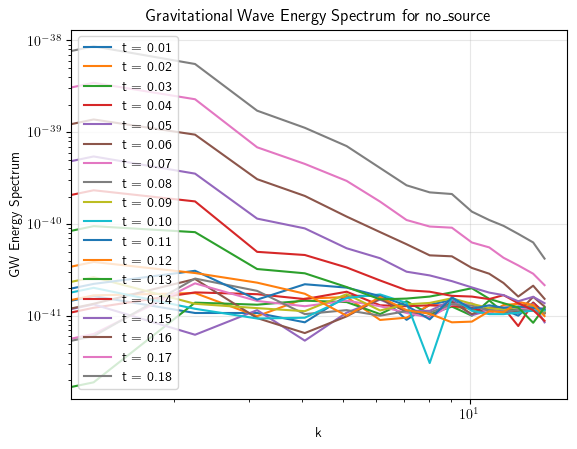

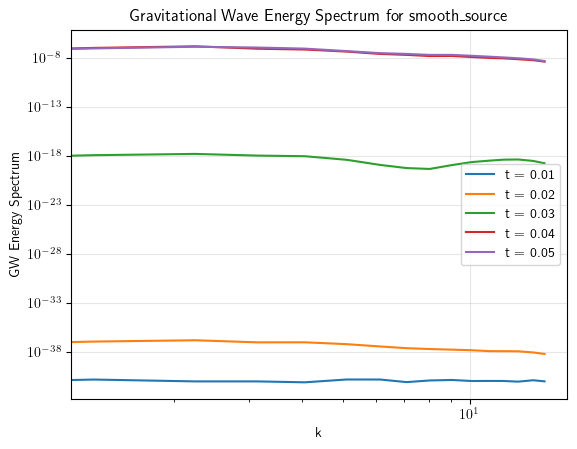

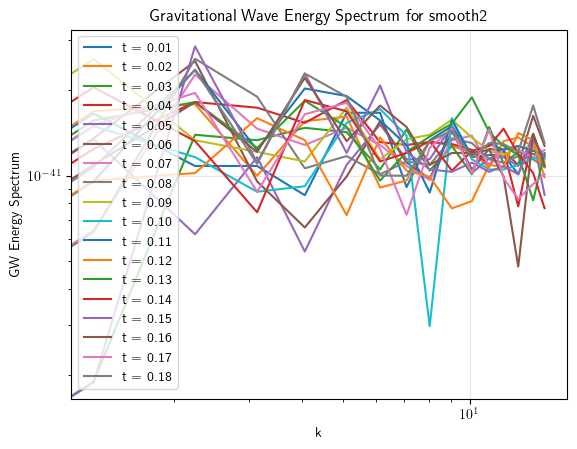

In [52]:
for id,sim in enumerate(powers_all):
    times = [i for i in range(0, len(sim.t))] 
    for idx in times:
        plt.loglog(sim.krms, sim.GWs[idx], label=f't = {sim.t[idx]-1:.2f}')
    plt.xlabel('k')
    plt.ylabel('GW Energy Spectrum')
    plt.title(f'Gravitational Wave Energy Spectrum for {powers_labels[id]}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


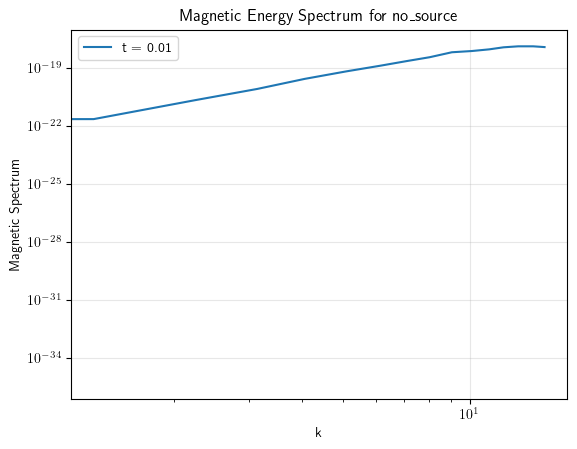

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


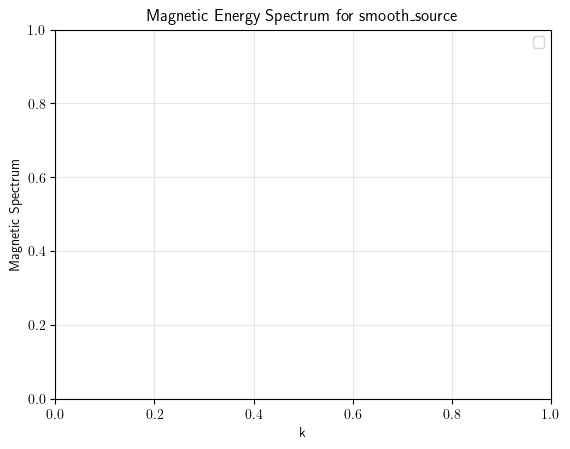

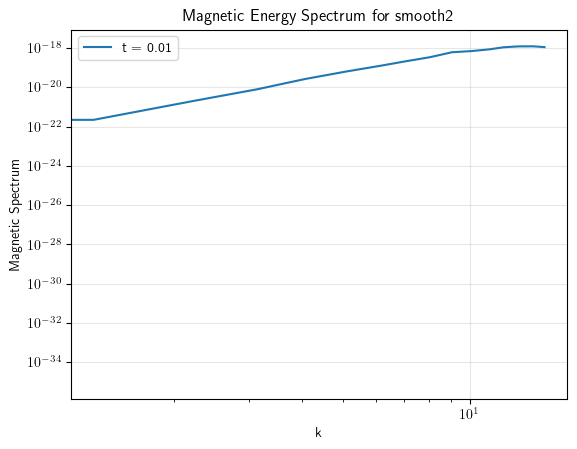

In [53]:
for id,sim in enumerate(powers_all):
    times = [i for i in range(0, len(sim.t)//10)] 
    for idx in times:
        plt.loglog(sim.krms, sim.mag[idx], label=f't = {sim.t[idx]-1:.2f}')
    plt.xlabel('k')
    plt.ylabel('Magnetic Spectrum')
    plt.title(f'Magnetic Energy Spectrum for {powers_labels[id]}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()